# Lab Solution: Early Stopping and Training Monitoring

## Introduction

You've recently joined HealthTech Analytics, a healthcare AI startup that's developing systems to predict patient readmission risk based on electronic health records. As a junior data scientist, you've been tasked with implementing a neural network model, which has been showing promising results but has inconsistent performance.

Your manager explains that the model sometimes performs well, but other times it overfits to training data or fails to converge properly. She suspects that proper training monitoring and early stopping strategies might solve these issues, making the model more reliable for clinical applications.

The Chief Data Officer has emphasized that the company can't afford to waste computational resources on models that aren't learning effectively, and clinical staff need stable, reliable predictions. You'll need to implement proper training monitoring and callbacks to ensure the model trains efficiently and generalizes well to new patient data.

## Part 0: Import Libraries and Set Up Environment

In [38]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, TensorBoard
from tensorflow.keras.optimizers import Adam

from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os

# Set random seeds for reproducibility
import random
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

## Part 1: Load and Explore Dataset

The dataset contains information from diabetic patients with various features such as age, gender, lab results, medical history, and a target variable indicating whether the patient was readmitted within 30 days, after 30 days, or not at all.

In [39]:
# Load in Data
patient_data = pd.read_csv("C:/Users/HK/Desktop/FI Data Science/Labs and Assignment/AD 09 Natural Language Processing, Time Series  and Neural Networks/readmission_data.csv")
patient_data.info()
patient_data.head()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


Dataset shape: (101766, 50)
Readmission rate: readmitted
NO     0.539119
>30    0.349282
<30    0.111599
Name: proportion, dtype: float64


Text(0.5, 1.0, 'Distribution of Readmissions')

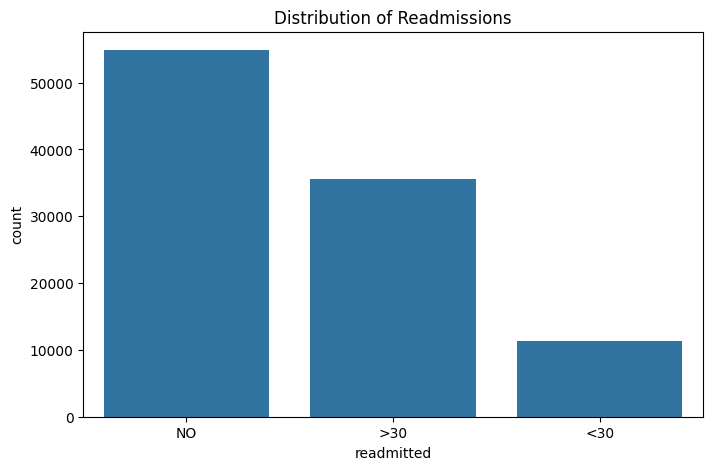

In [40]:
# Let's explore the dataset
print(f"Dataset shape: {patient_data.shape}")
print(f"Readmission rate: {patient_data['readmitted'].value_counts(normalize=True)}")

# Check class balance
plt.figure(figsize=(8, 5))
sns.countplot(x='readmitted', data=patient_data)
plt.title('Distribution of Readmissions')

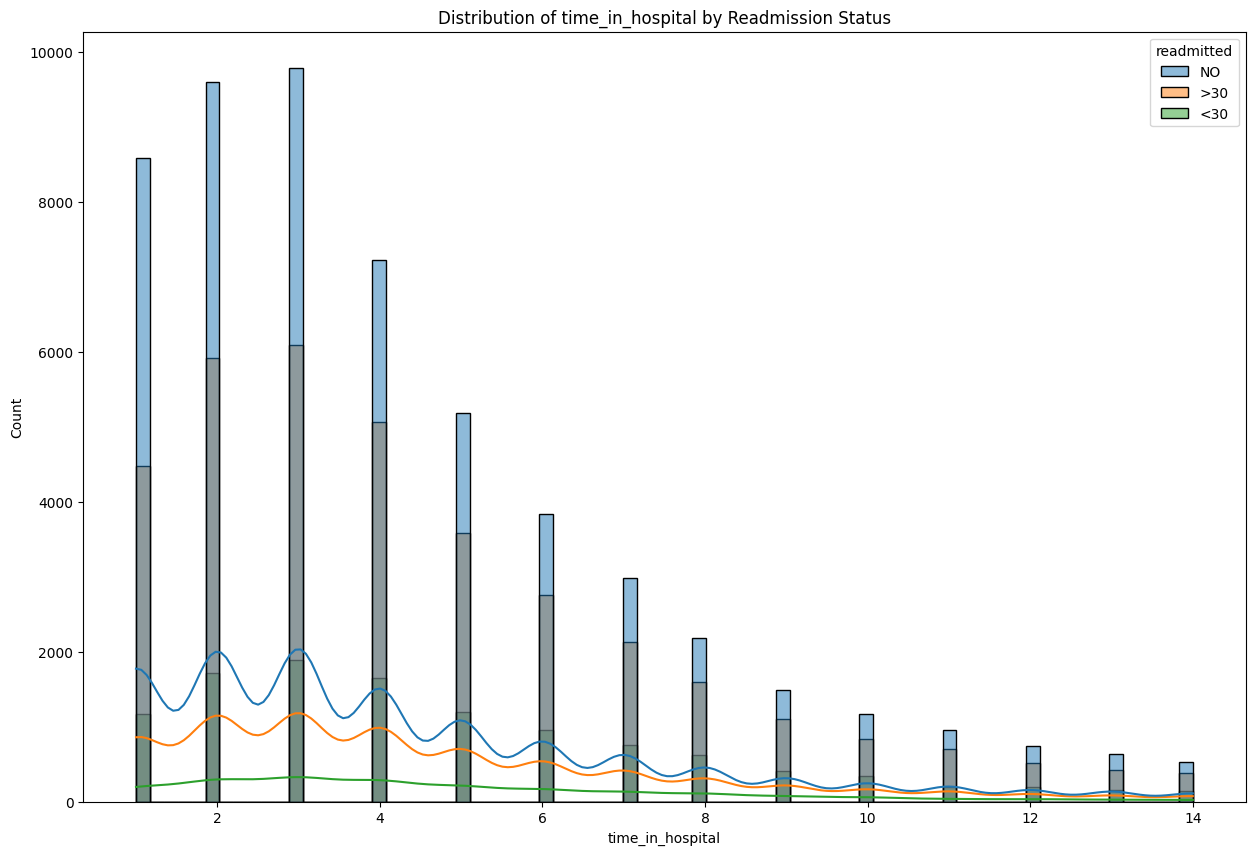

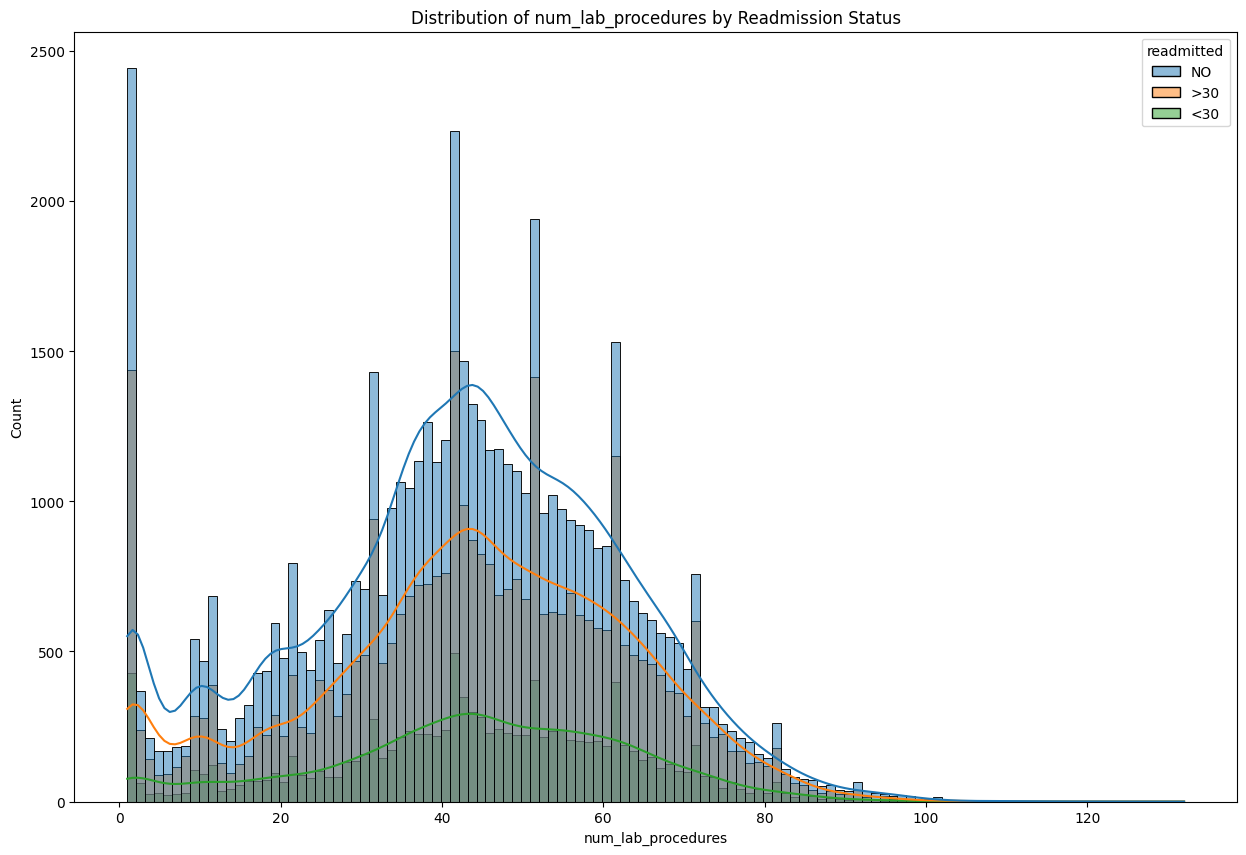

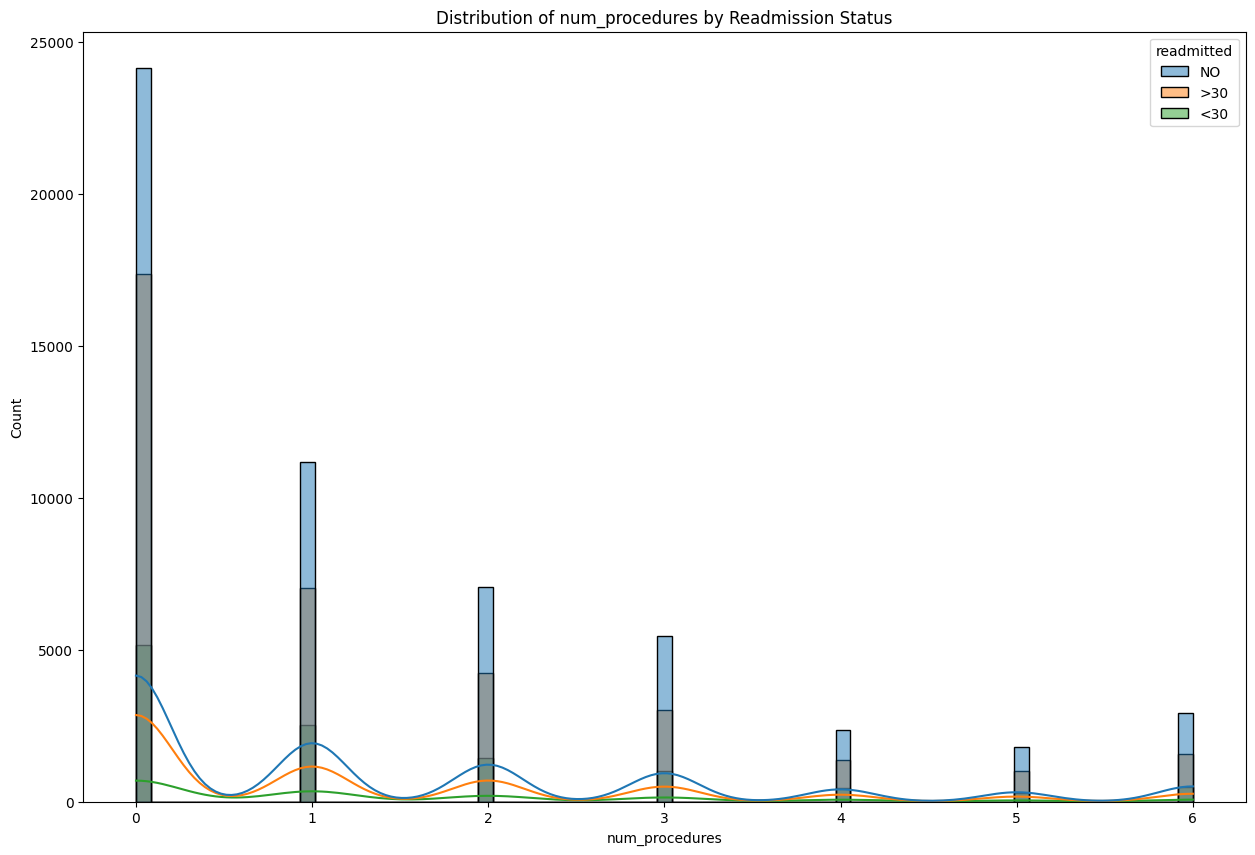

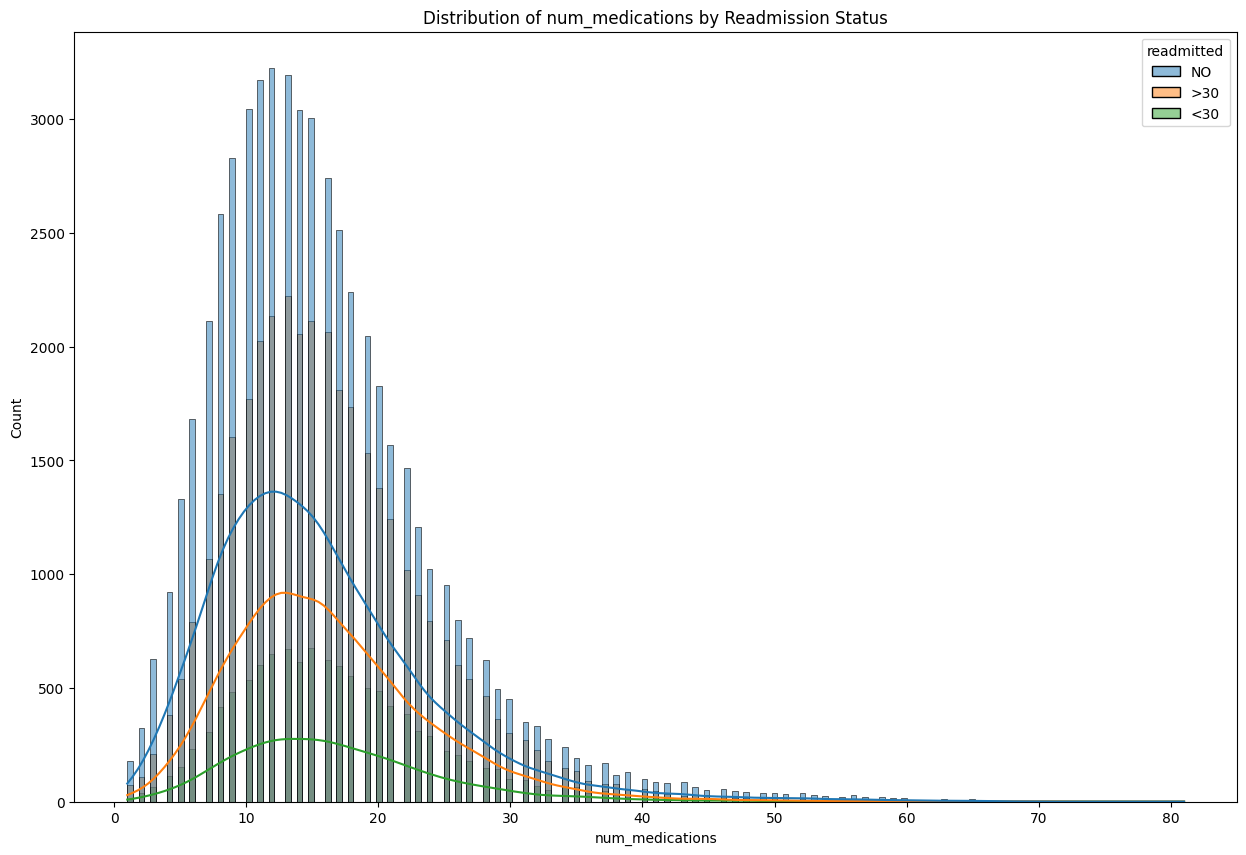

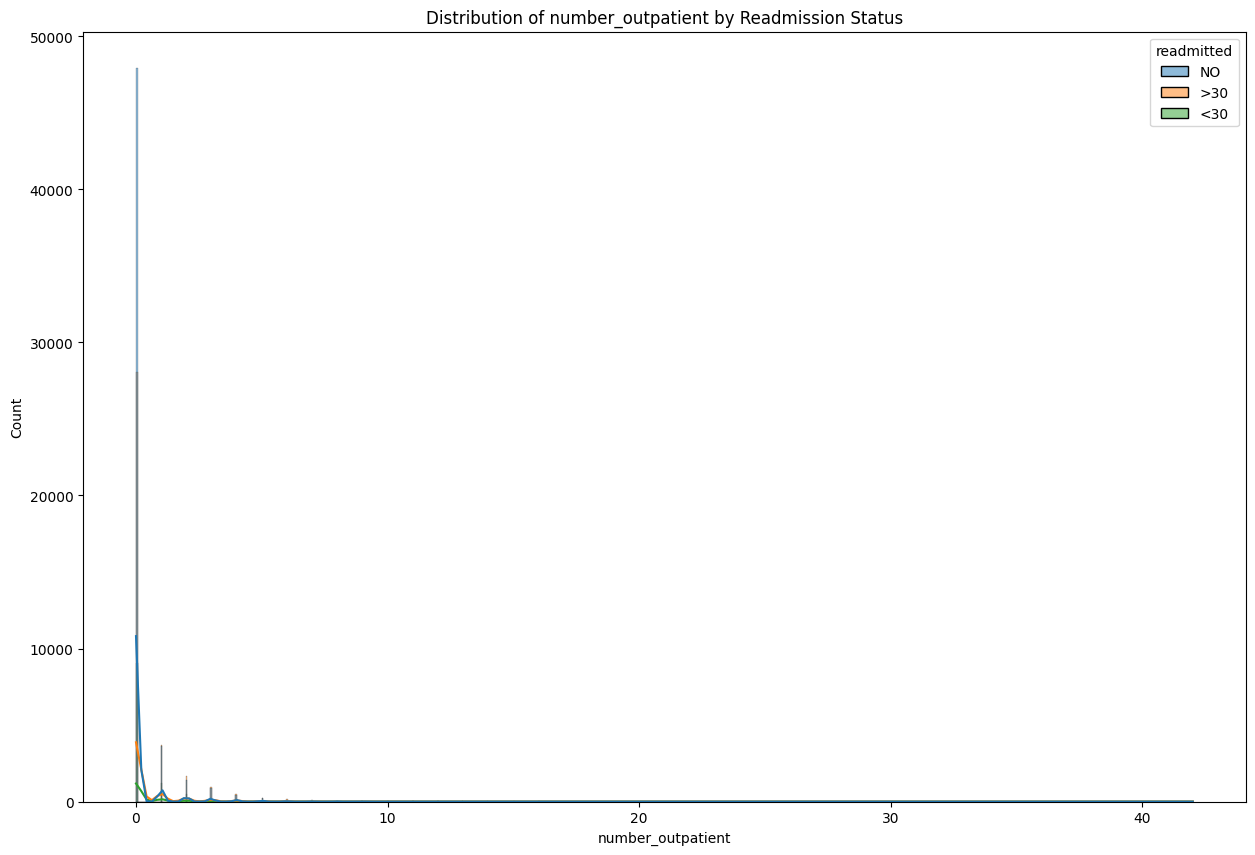

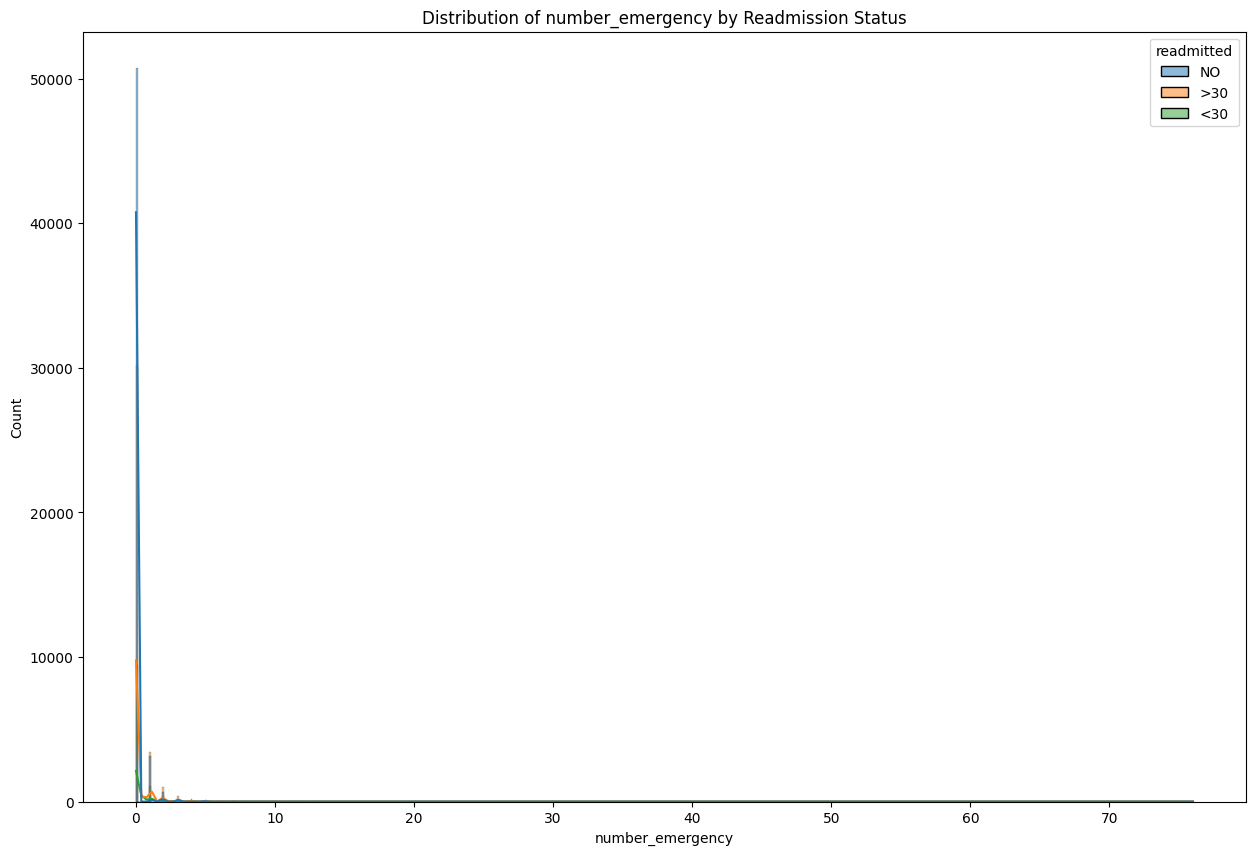

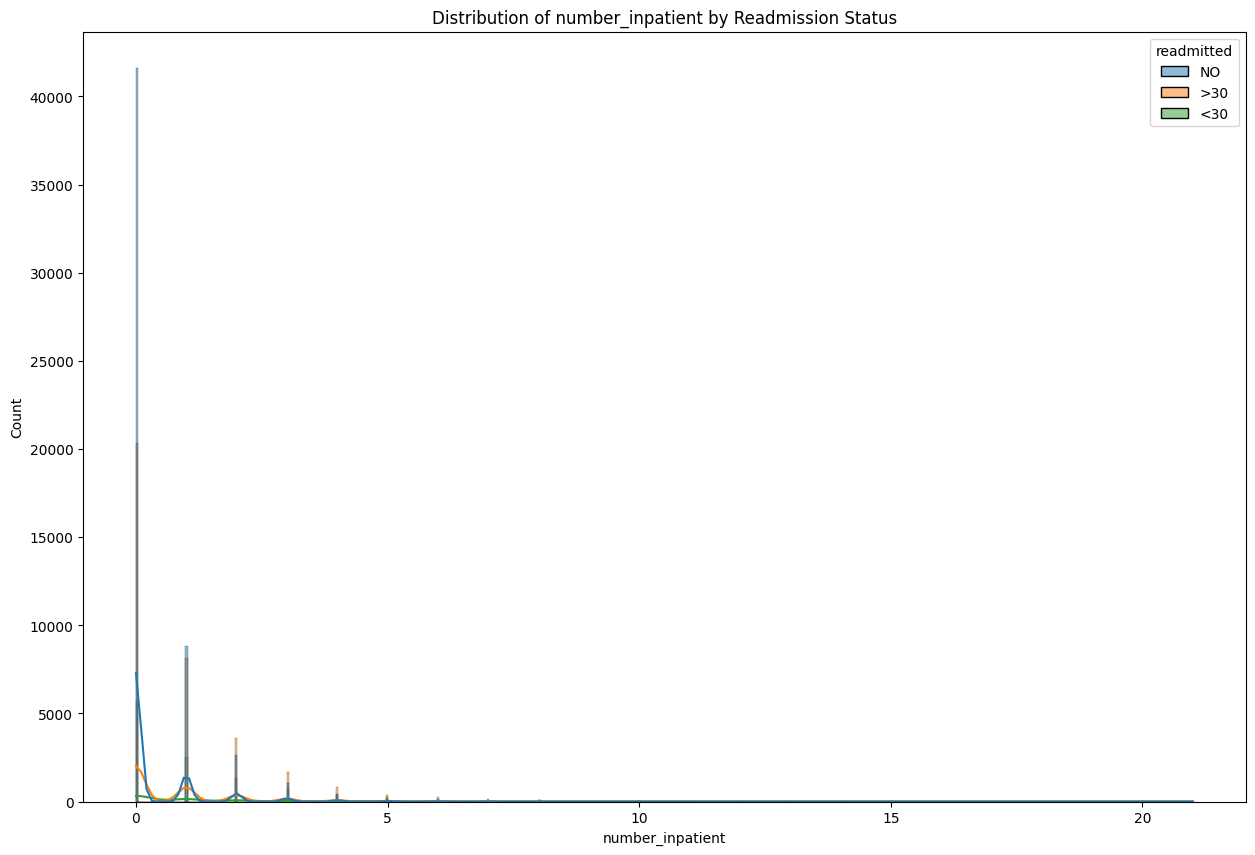

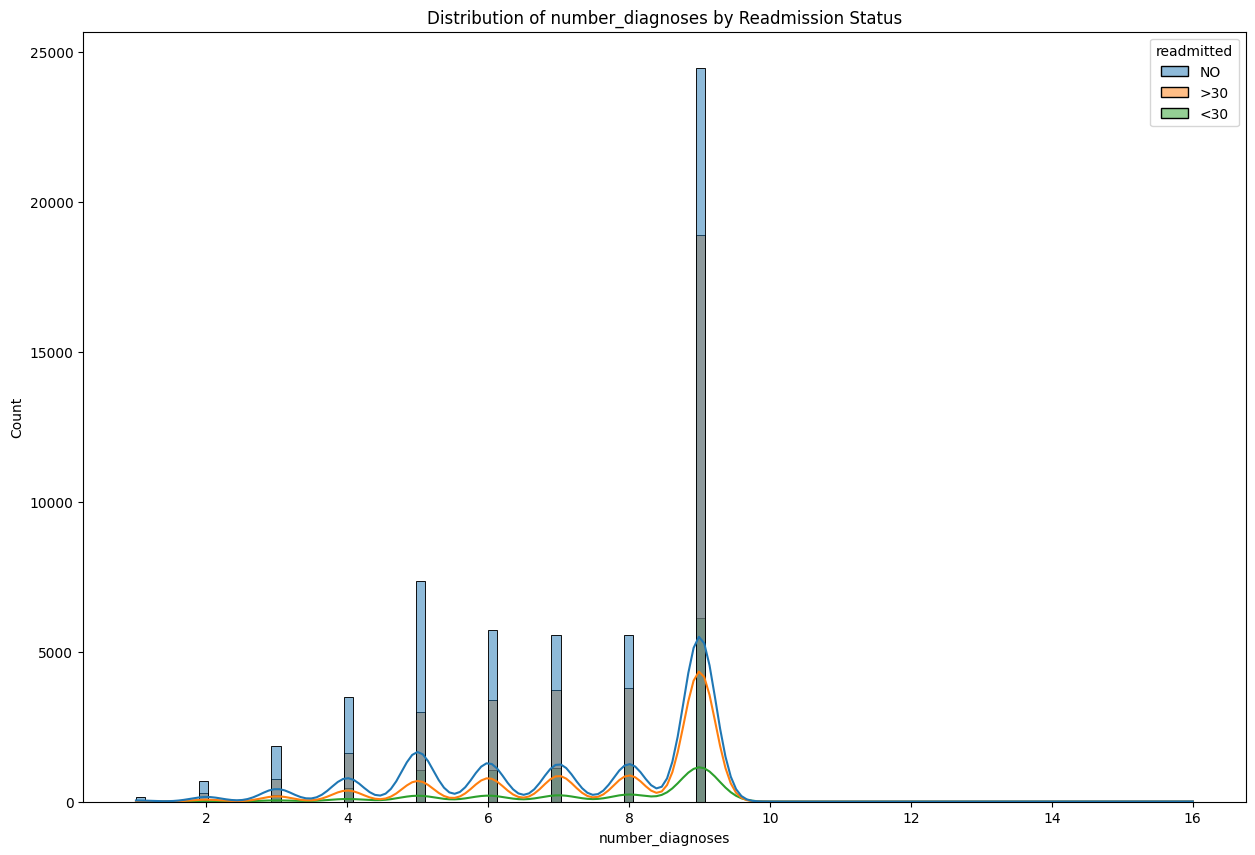

In [41]:
# Seperate out features for visualization
num_features = patient_data.select_dtypes(include='number')
# Irrelevant or categoricall
num_features.drop(['encounter_id', 'patient_nbr', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id'], axis=1, inplace=True)

# Look at numerical feature distributions
for i, col in enumerate(num_features):
    plt.figure(figsize=(15, 10))
    sns.histplot(data=patient_data, x=col, hue='readmitted', kde=True)
    plt.title(f'Distribution of {col} by Readmission Status')

C:\Users\HK\AppData\Local\Temp\ipykernel_22996\1473184278.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_columns = patient_data.select_dtypes(include='object')
c:\Users\HK\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\plotting\_matplotlib\core.py:599: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyp

<Figure size 1500x1000 with 0 Axes>

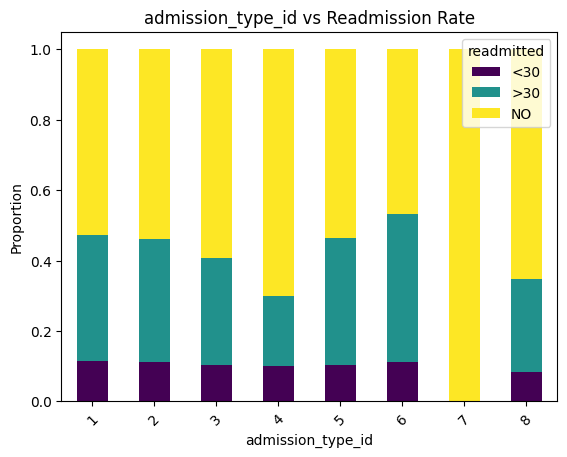

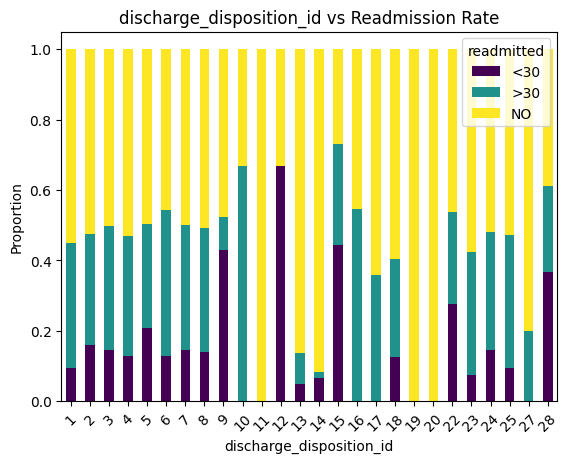

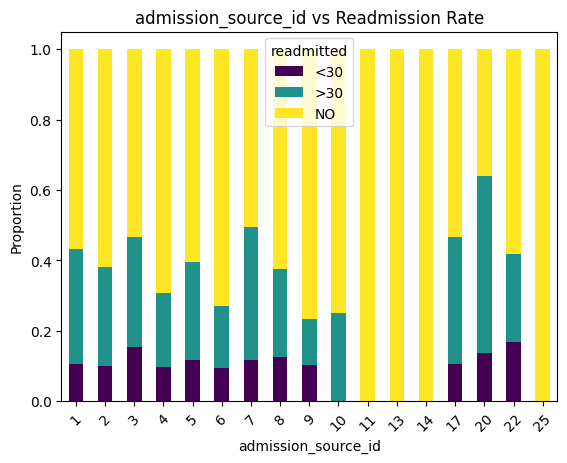

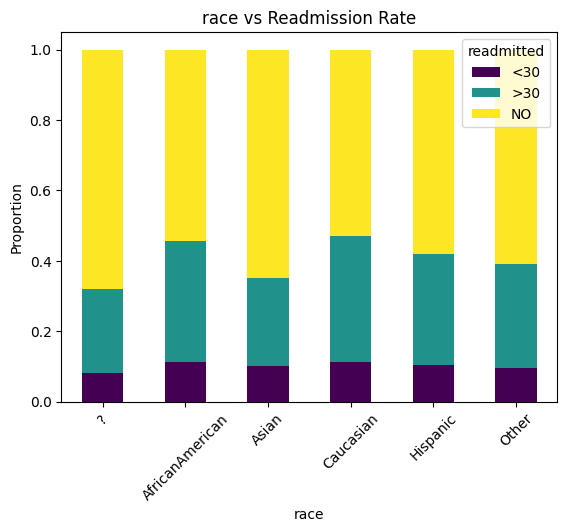

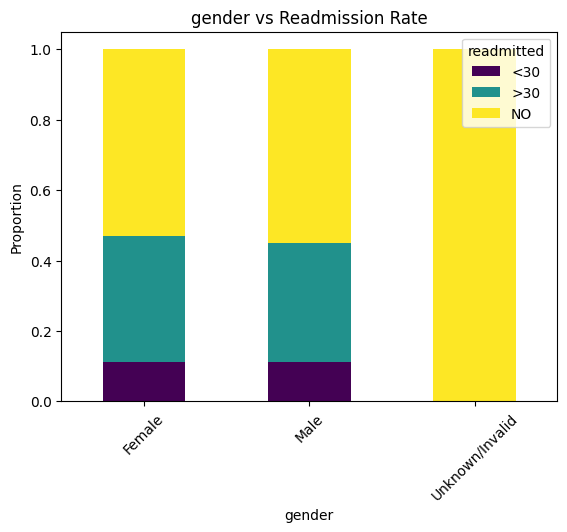

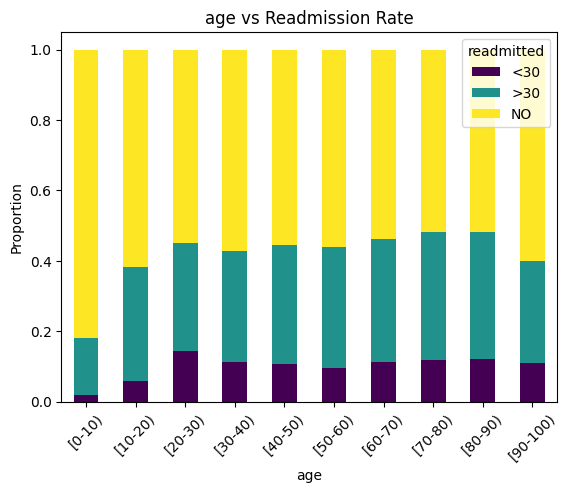

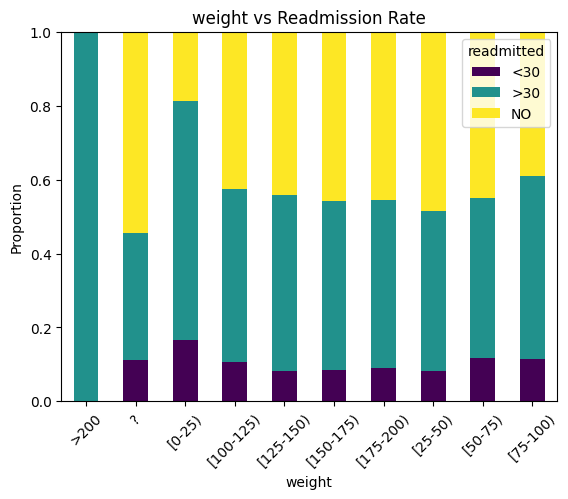

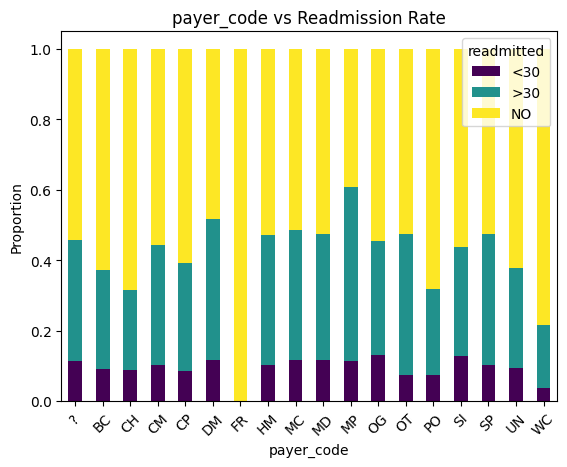

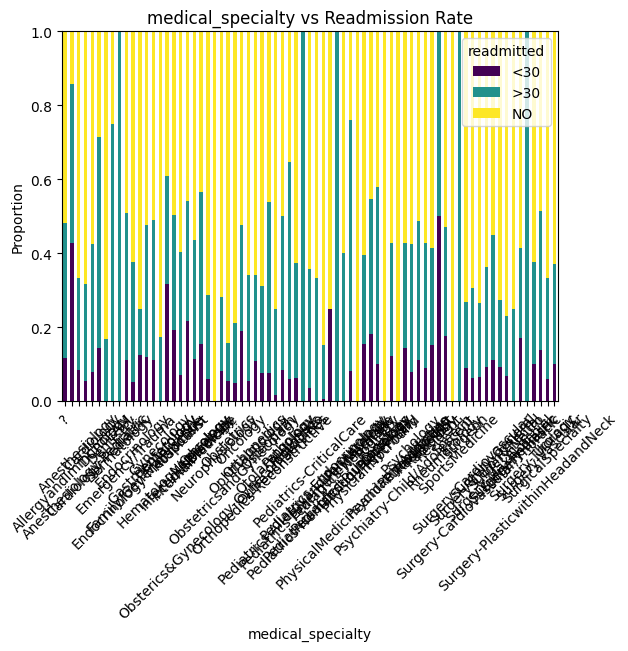

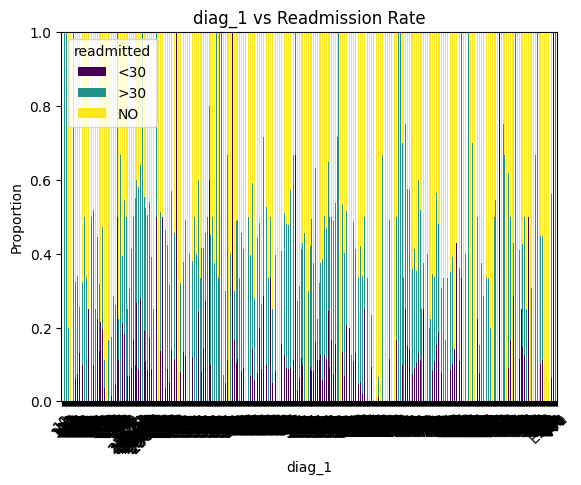

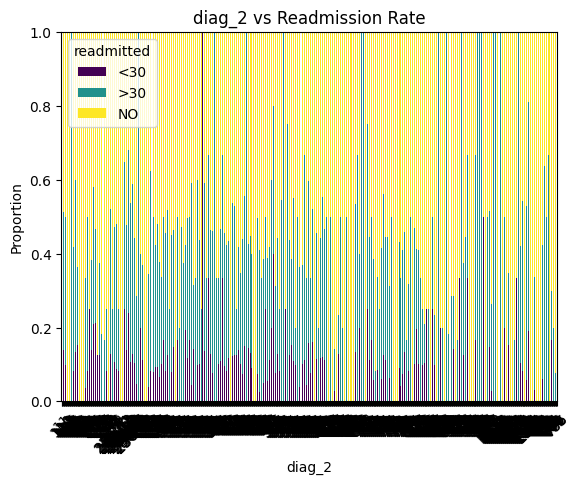

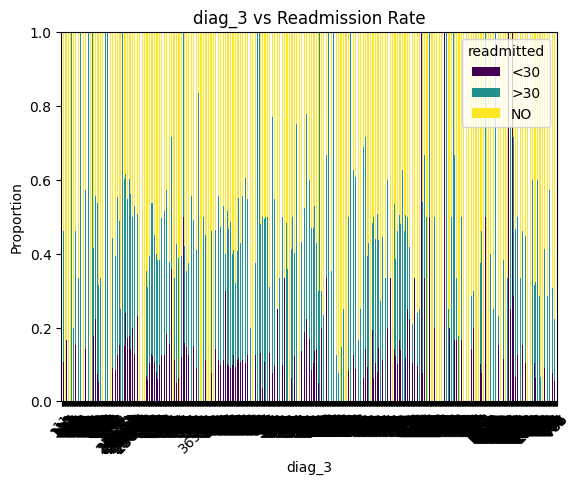

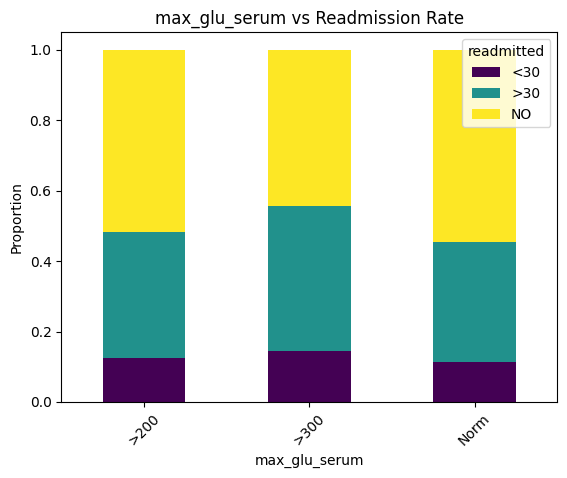

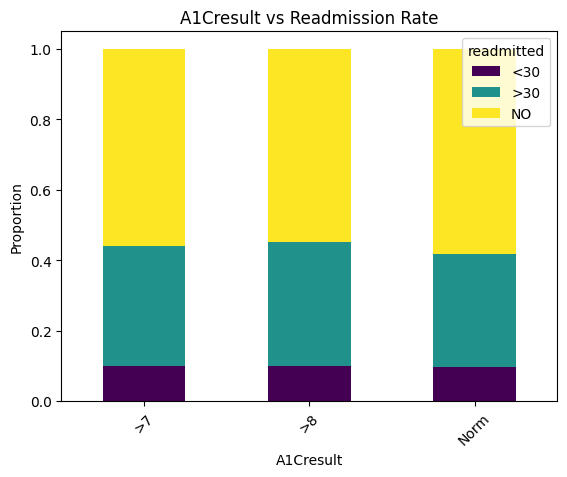

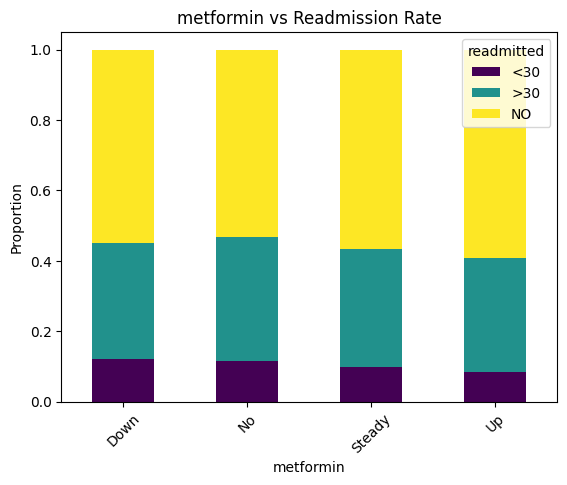

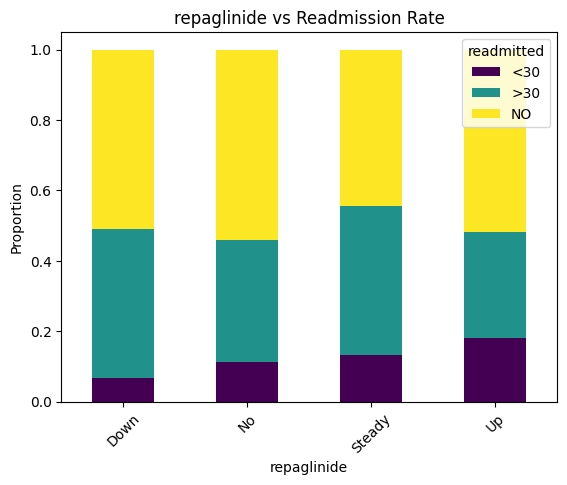

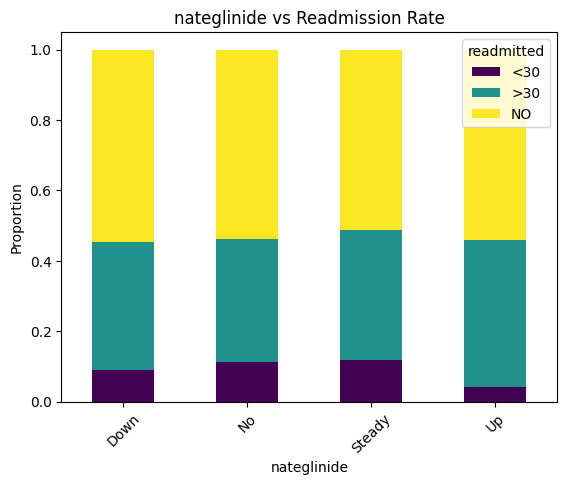

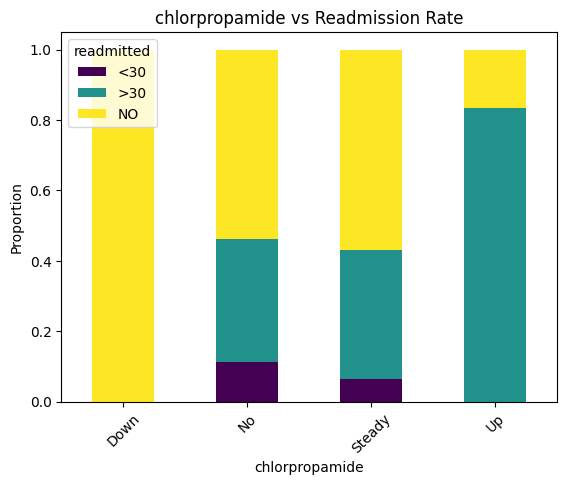

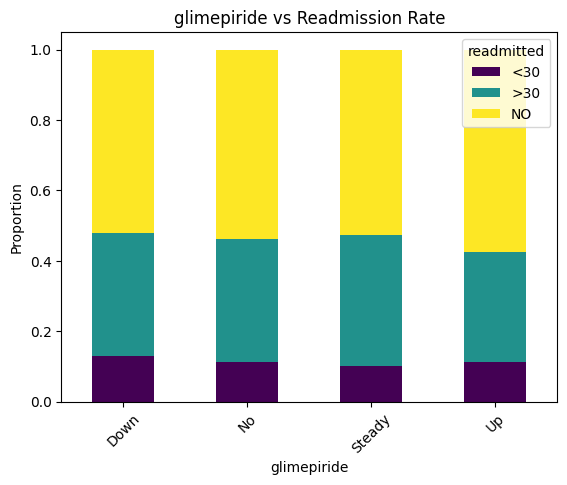

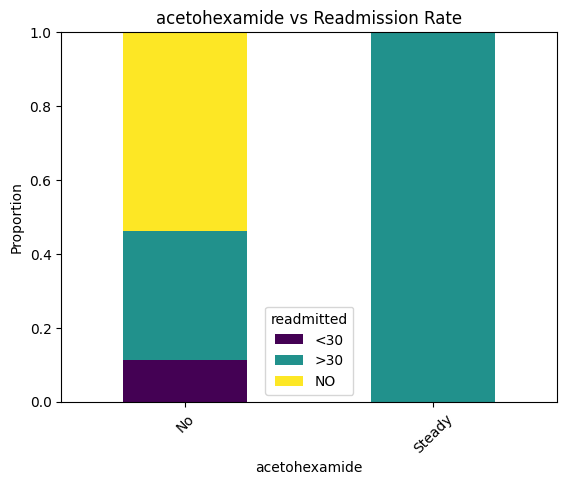

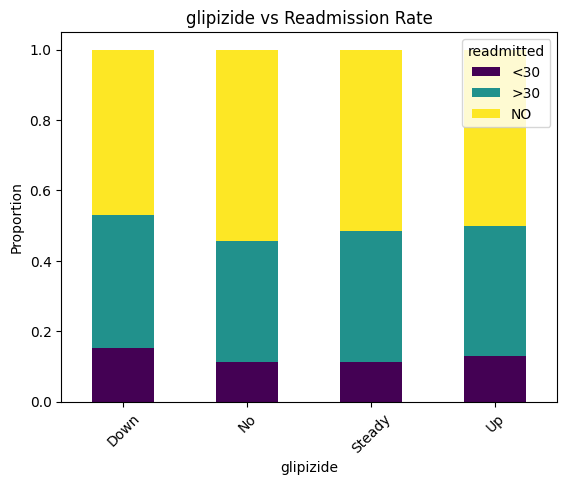

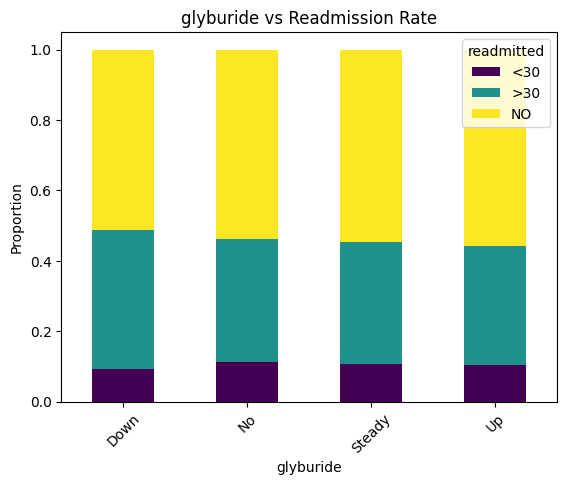

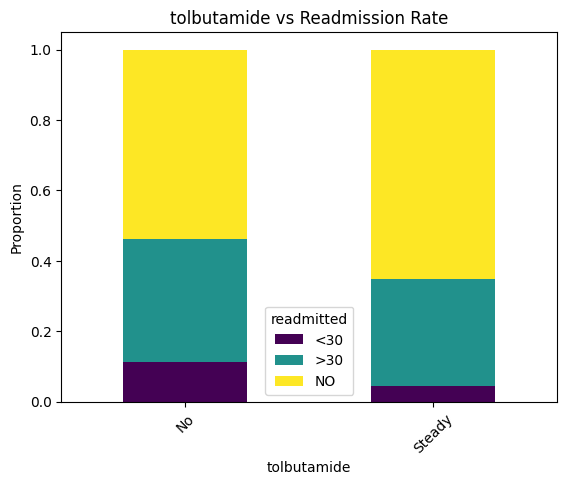

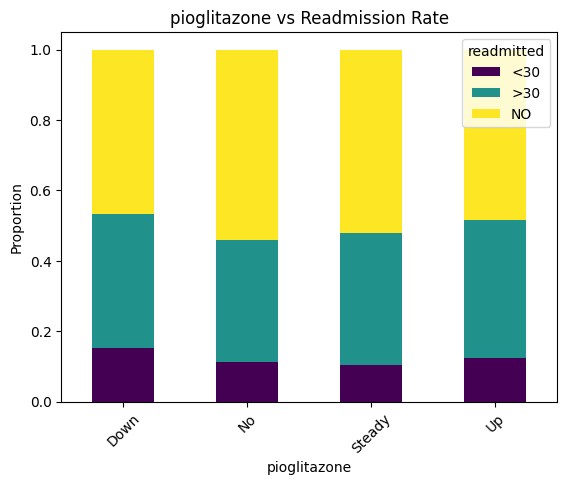

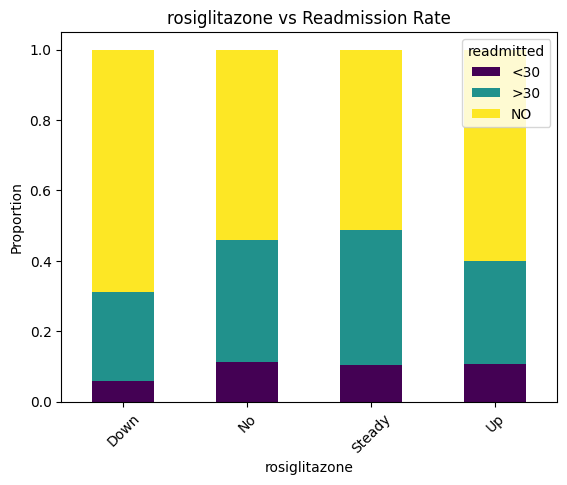

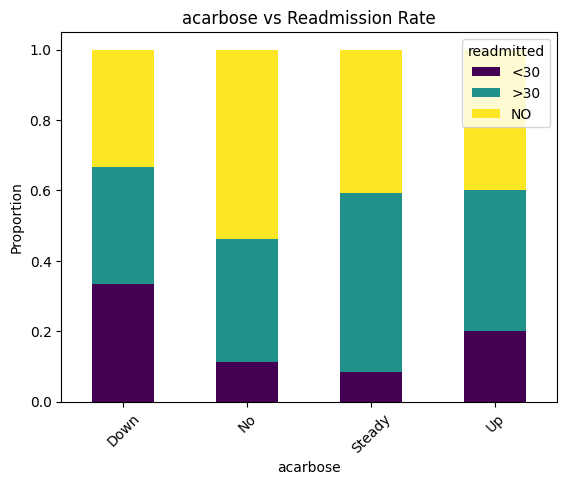

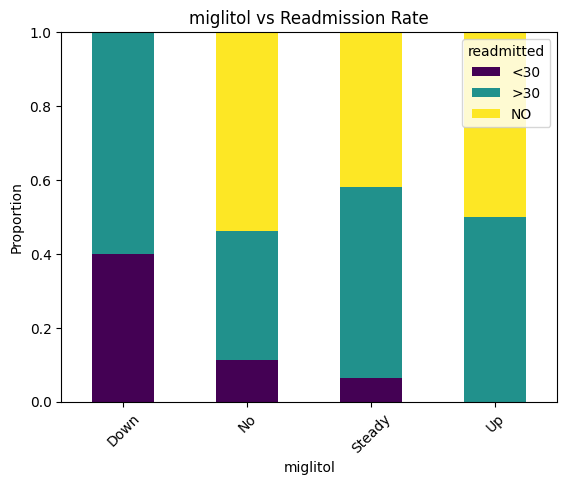

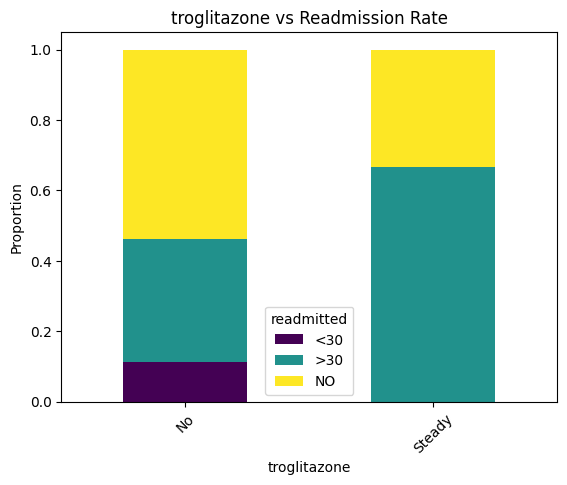

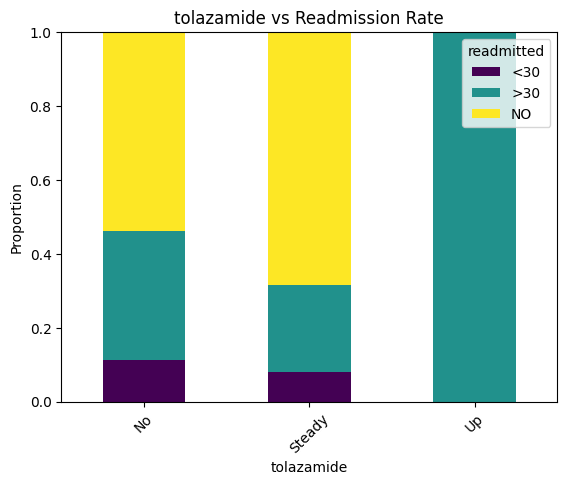

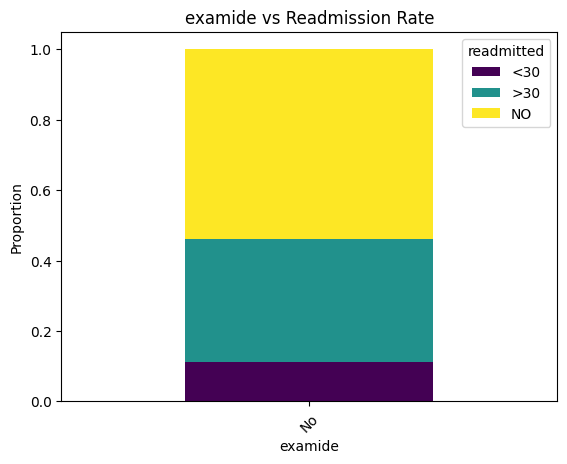

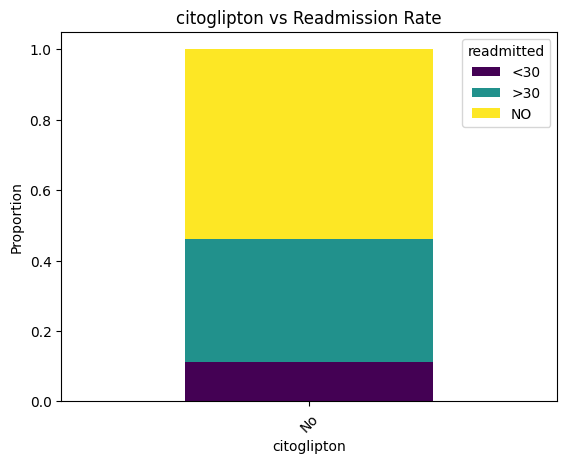

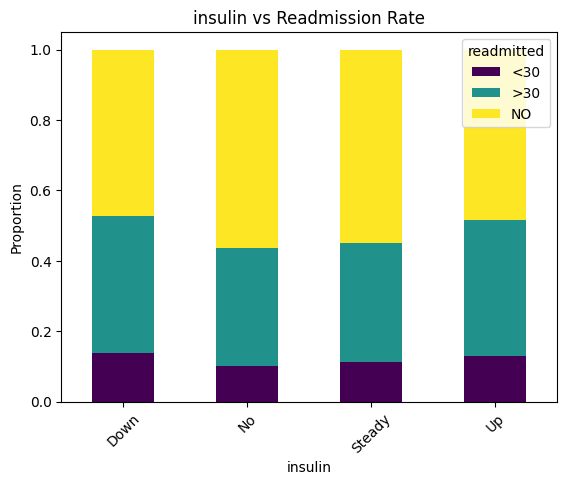

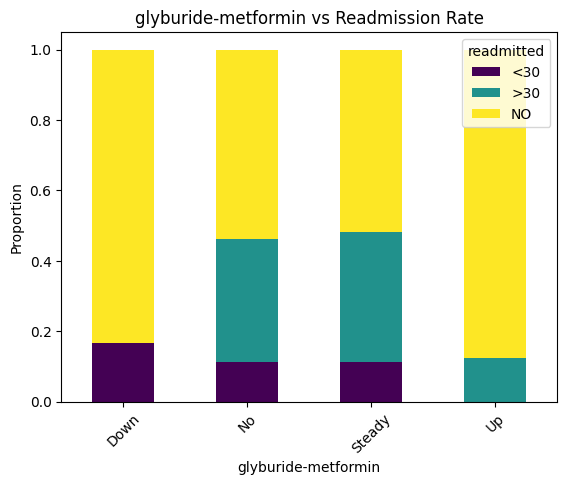

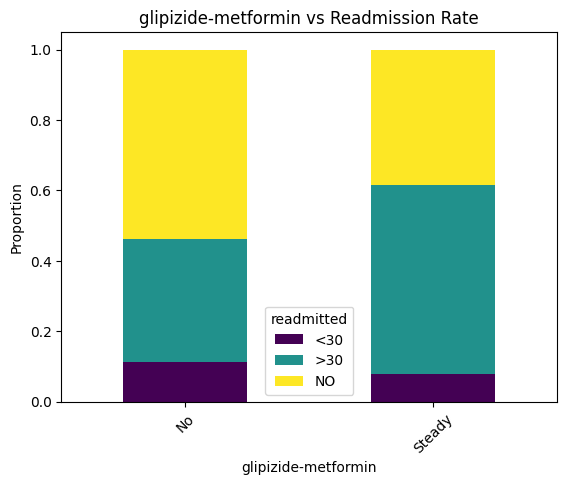

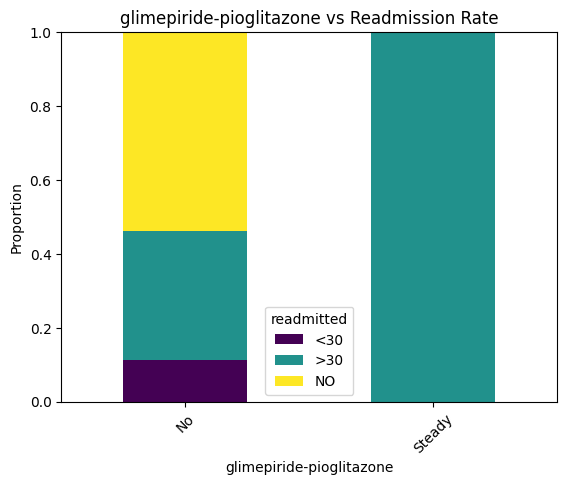

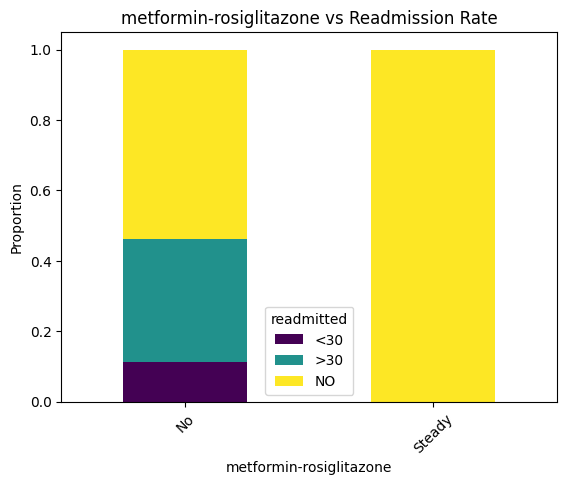

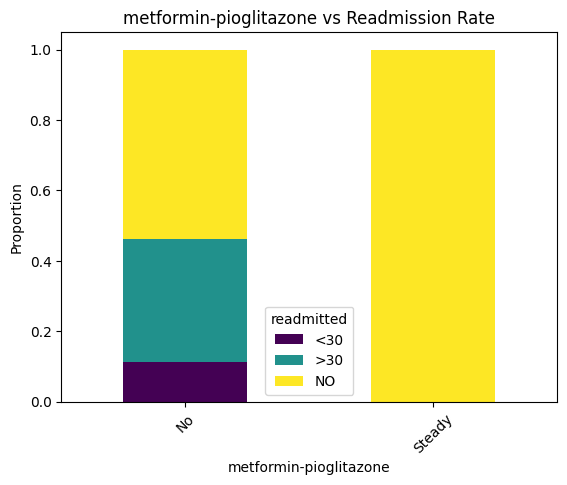

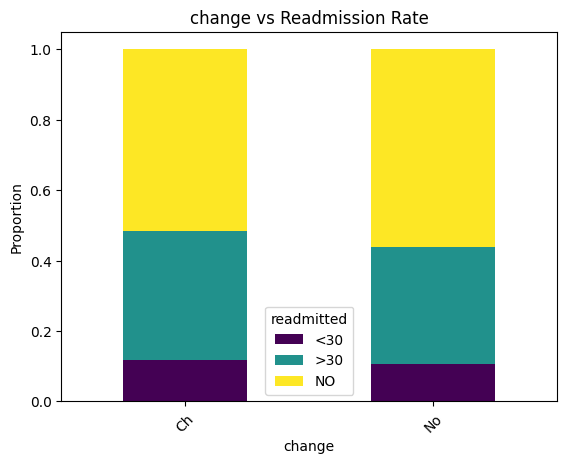

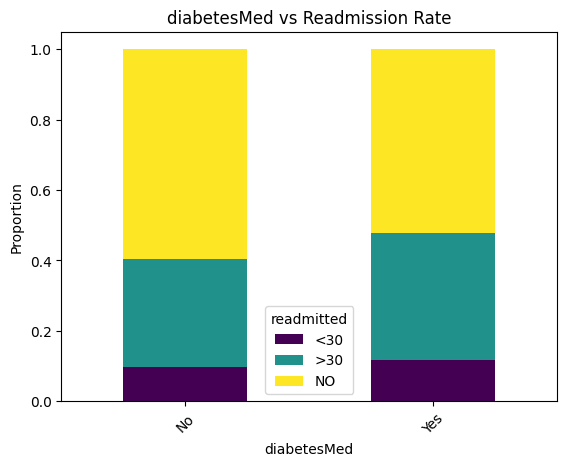

In [42]:
# Seperate out features for visualization
categorical = ['admission_type_id', 'discharge_disposition_id', 'admission_source_id']
cat_columns = patient_data.select_dtypes(include='object')
cat_cols = list(cat_columns.columns)
categorical.extend(cat_cols)
categorical.remove('readmitted')
cat_features = patient_data[categorical]

# Categorical features
plt.figure(figsize=(15, 10))
for i, col in enumerate(cat_features):
    crosstab = pd.crosstab(patient_data[col], patient_data['readmitted'], normalize='index')
    crosstab.plot(kind='bar', stacked=True, colormap='viridis')
    plt.title(f'{col} vs Readmission Rate')
    plt.ylabel('Proportion')
    plt.xticks(rotation=45)

## Part 2: Implement Baseline Model
First you need to prepare the data for modeling



In [43]:
# Prepare data for modeling
# We will look to combine readmission to make this binary
patient_data['readmitted'] = patient_data['readmitted'].map({'<30': 1, '>30': 1, 'NO': 0})

# These columns hold no meaning are just unique identifiers and readmitted is our target
cols_to_drop = ['encounter_id', 'patient_nbr', 'readmitted']
X = patient_data.drop(columns=cols_to_drop)
y = patient_data['readmitted']

# Split data into train, validation, and test sets
from sklearn.model_selection import train_test_split

# First split: 80% train+validation, 20% test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: 75% train, 25% validation (resulting in 60% train, 20% validation, 20% test overall)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

In [44]:
# Run this cell without changes
# Preprocess data with Column Transformer pipeline
# To prevent high dimenstionality we will target encode the diagnosis codes rather than one hot encode
target_encode_cols = ['diag_1', 'diag_2', 'diag_3']
ohe_cols = [col for col in categorical if col not in target_encode_cols]
num_cols = num_features.columns

# Create the preprocessing function
num_pipe = Pipeline(steps=[('impute_num', SimpleImputer(strategy='median')),
                           ('scaler', StandardScaler())])

ohe_pipe = Pipeline(steps=[('impute_cat', SimpleImputer(strategy='constant', fill_value='?')),
                           ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore'))])

tarenc_pipe = Pipeline(steps=[('impute_cat', SimpleImputer(strategy='constant', fill_value='?')),
                              ('tar_encode', TargetEncoder(target_type='binary'))])

col_trans = ColumnTransformer(transformers=[('num', num_pipe, num_cols),
                                            ('cat', ohe_pipe, ohe_cols),
                                            ('tar', tarenc_pipe, target_encode_cols)],
                              remainder='passthrough')

# Need to provide y_train for the target encoder
X_train_pro = col_trans.fit_transform(X_train, y_train)
X_val_pro = col_trans.transform(X_val)
X_test_pro = col_trans.transform(X_test)

print(f"Training set: {X_train_pro.shape} samples")
print(f"Validation set: {X_val_pro.shape} samples")
print(f"Test set: {X_test_pro.shape} samples")

c:\Users\HK\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2, 8, 23] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Training set: (61059, 220) samples
Validation set: (20353, 220) samples
Test set: (20354, 220) samples


c:\Users\HK\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [8, 25, 33] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [ ]:
# Create a baseline with two hidden layers, use the relu activation function, select an appropriate number of nodes (64, 32)
# Don't forget your output layer for binary classification
def create_baseline_model(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        # Use Adam
        optimizer=Adam(),
        # Select appropriate loss for binary classification
        loss='binary_crossentropy',
        # Evaluate based on recall
        metrics=[tf.keras.metrics.Recall()]
    )
    
    return model

# Create and train the baseline model
baseline_model = create_baseline_model(X_train_pro.shape[1])
baseline_model.summary()

# Train the model without any callbacks
baseline_history = baseline_model.fit(
    X_train_pro, y_train,
    epochs=50,  # Train for a fixed number of epochs
    batch_size=32,
    validation_data=(X_val_pro, y_val),
    verbose=1
)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 64)             │        14,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,257 (63.50 KB)

 Trainable params: 16,257 (63.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1909/1909 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - loss: 0.6355 - recall_7: 0.5062 - val_loss: 0.6222 - val_recall_7: 0.6026
Epoch 2/50
1909/1909 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 0.6197 - recall_7: 0.5610 - val_loss: 0.6187 - val_recall_7: 0.5964
Epoch 3/50
1909/1909 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.6140 - recall_7: 0.5759 - val_loss: 0.6183 - val_recall_7: 0.6011
Epoch 4/50
1909/1909 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.6094 - recall_7: 0.5836 - val_loss: 0.6192 - val_recall_7: 0.6082
Epoch 5/50
1909/1909 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 0.6055 - recall_7: 0.5921 - val_loss: 0.6200 - val_recall_7: 0.5920
Epoch 6/50
1909/1909 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.6016 - recall_7: 0.5973 - val_loss: 0.6214 - val_recall_7: 0.5982
Epoch 7/50
1909/1909 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.5978 - recall_7: 0.6009 - val_loss: 0.6237 - val_recall_7: 0.6069
Epoch 8/50
1909/1909 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.5939 - recall_7: 0

## Part 3: Visualize Training and Validation curves
Important to visualize our training curves in order to understand model limitations and adapt the next iteration. Particularly important to understand the models bias and variance (over/under fitting).

637/637 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7570 - recall_6: 0.5532
Baseline Test Recall: 0.5532


KeyError: 'recall'

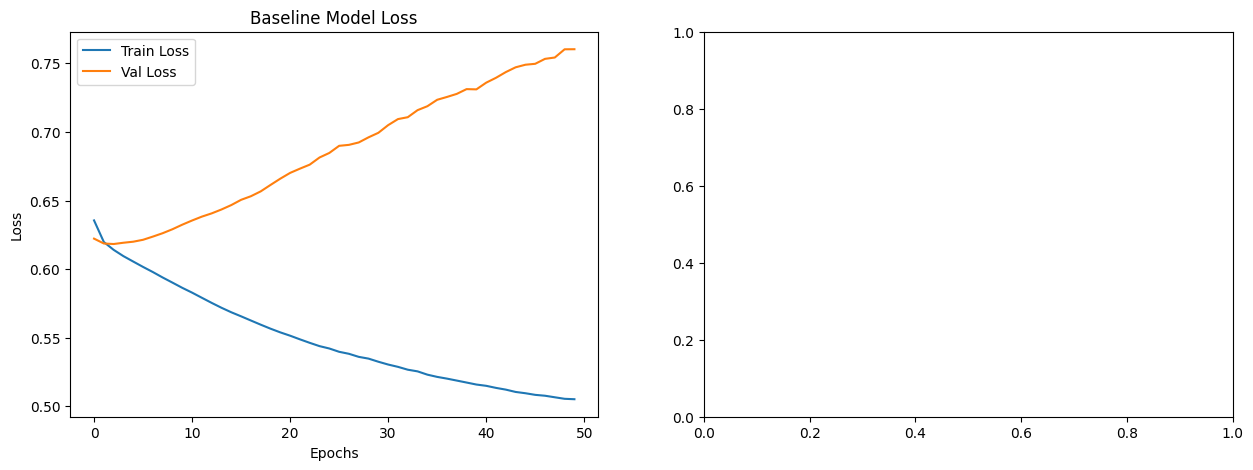

In [ ]:
# Evaluate the baseline model on testing data
baseline_test_loss, baseline_test_recall = baseline_model.evaluate(X_test_pro, y_test)
print(f"Baseline Test Recall: {baseline_test_recall:.4f}")

# Plot the training and validation loss/accuracy curves
def plot_training_history(history, title=''):
    plt.figure(figsize=(15, 5))
    
    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{title} Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    # Plot recall
    plt.subplot(1, 2, 2)
    plt.plot(history.history['recall'], label='Train Recall')
    plt.plot(history.history['val_recall'], label='Val Recall')
    plt.title(f'{title} Recall')
    plt.xlabel('Epochs')
    plt.ylabel('Recall')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# Plot baseline model training history
plot_training_history(baseline_history, title='Baseline Model')

## Part 4: Implement Callbacks for Monitoring and Early Stopping

Clear sign of model overfitting and gradient problems. Now, let's implement callbacks to monitor training and prevent overfitting. We will also provide a more complex network to attempt to address the overfitting.

In [ ]:
# Implement EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Implement ModelCheckpoint callback to save the best model
checkpoint_filepath = './best_model.keras'
model_checkpoint = ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Implement TensorBoard callback for visualization
log_dir = "logs/fit/" + datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(
    log_dir=log_dir,
    histogram_freq=1
)

# Don't change this one
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,        # Reduce learning rate by 80%
    patience=3,        # Wait 5 epochs of no improvement
    min_lr=0.000001,    # Don't go below this learning rate
    verbose=1          # Print when learning rate changes
)

# Combine all callbacks into a list
callbacks = [
    early_stopping,
    model_checkpoint,
    tensorboard_callback,
    reduce_lr
]

In [ ]:
# Run this cell without changes
# Create an improved model with gradient problem mitigation strategies and train with callbacks
def create_improved_model(input_dim):
    model = Sequential()
    
    # First layer
    model.add(Input((input_dim,)))
    model.add(Dense(64))
    model.add(BatchNormalization())
    model.add(LeakyReLU())
    model.add(Dropout(0.2))  
    
    # Second layer
    model.add(Dense(32))
    model.add(BatchNormalization())
    model.add(LeakyReLU())
    model.add(Dropout(0.2))
    
    # Output layer
    model.add(Dense(1, activation='sigmoid'))
    
    # Use Adam optimizer with gradient clipping
    optimizer = Adam(learning_rate=0.001, clipvalue=.5)
    
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['recall']
    )
    
    return model

# Create and compile the improved model
improved_model = create_improved_model(X_train_pro.shape[1])
improved_model.summary()

# Train the improved model with the callbacks
improved_history = improved_model.fit(
    X_train_pro, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val_pro, y_val),
    callbacks=callbacks,
    verbose=1
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │        14,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,641 (65.00 KB)

 Trainable params: 16,449 (64.25 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/100
1897/1909 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6779 - recall: 0.5074
Epoch 1: val_loss improved from None to 0.62886, saving model to ./best_model.keras

Epoch 1: finished saving model to ./best_model.keras
1909/1909 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 0.6541 - recall: 0.5211 - val_loss: 0.6289 - val_recall: 0.4017 - learning_rate: 0.0010
Epoch 2/100
1909/1909 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6326 - recall: 0.5415
Epoch 2: val_loss improved from 0.62886 to 0.62653, saving model to ./best_model.keras

Epoch 2: finished saving model to ./best_model.keras
1909/1909 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.6296 - recall: 0.5490 - val_loss: 0.6265 - val_recall: 0.4026 - learning_rate: 0.0010
Epoch 3/100
1908/1909 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6261 - recall: 0.5539
Epoch 3: val_loss improved from 0.62653 to 0.62561, saving model to ./best_model.keras

Epoch 3: finished saving model to ./best_model.keras
1909/1909 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/st

## Part 5: Analyze Training Results
Again, it is always important to look at curves. Here we should see way less overfitting and platued losses which tell us the model has gone about as far as it can go with the data at hand.

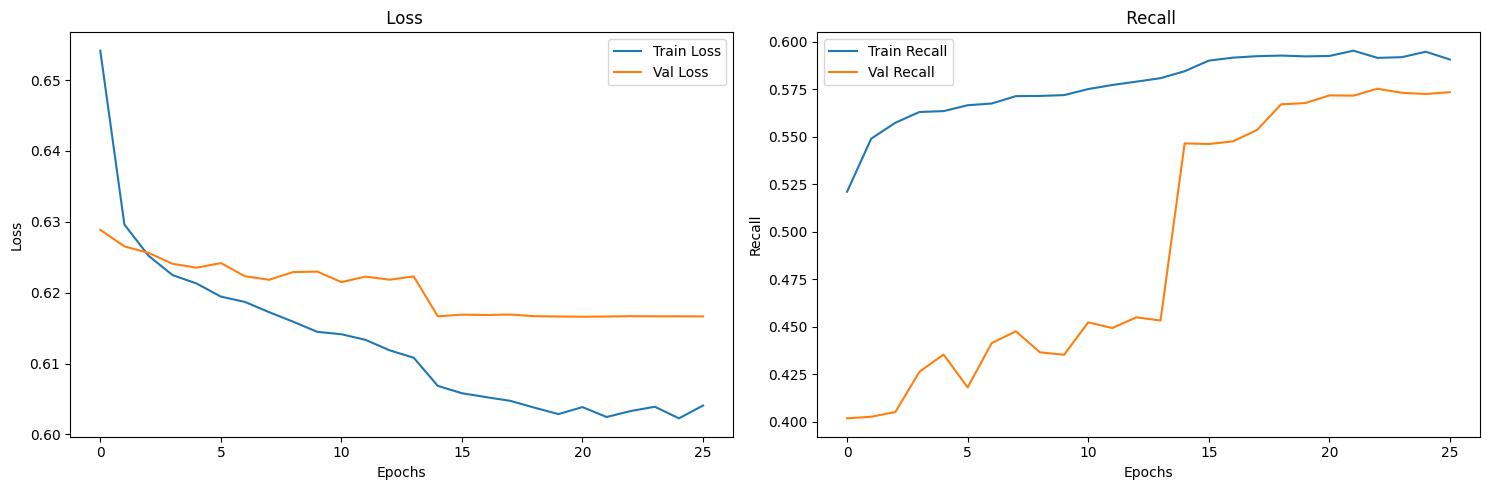

637/637 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.6175 - recall: 0.5716
Improved Model (Final) Test Recall: 0.5716
637/637 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6175 - recall: 0.5716
Best Model (Checkpoint) Test Recall: 0.5716
Baseline Test Recall: 0.5532
Early Stopping activated at epoch 26 of 100


In [ ]:
# Plot the training history with early stopping
plot_training_history(improved_history)

# Load the best model saved by ModelCheckpoint
best_model = tf.keras.models.load_model('./best_model.keras')

# Evaluate the final improved model
improved_test_loss, improved_test_recall = improved_model.evaluate(X_test_pro, y_test, verbose=1)
print(f"Improved Model (Final) Test Recall: {improved_test_recall:.4f}")

# Evaluate the best model (saved by checkpoint)
best_test_loss, best_test_recall = best_model.evaluate(X_test_pro, y_test, verbose=1)
print(f"Best Model (Checkpoint) Test Recall: {best_test_recall:.4f}")

# Compare with baseline
print(f"Baseline Test Recall: {baseline_test_recall:.4f}")
print(f"Early Stopping activated at epoch {len(improved_history.history['loss'])} of 100")

In [ ]:
# Load TensorBoard extension
%load_ext tensorboard

# Launch TensorBoard
%tensorboard --logdir=logs/fit

# Note: TensorBoard output will appear in the notebook
# We can examine histograms of weights and gradients, model graph,
# and other useful visualizations

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


ERROR: Could not find `tensorboard`. Please ensure that your PATH
contains an executable `tensorboard` program, or explicitly specify
the path to a TensorBoard binary by setting the `TENSORBOARD_BINARY`
environment variable.

When training complex machine learning models, the relationship between model complexity and data quality is crucial. Even the most sophisticated neural network architecture can plateau if the loss stops decreasing, indicating that the model has reached the limits of what it can learn from the available data. At this point, rather than adding more layers or parameters, the focus should shift to improving data quality, diversity, and relevance to the specific task. Better data—whether that means more accurate labels, more representative samples, or enhanced feature engineering—often proves more valuable than increased model complexity for breaking through performance plateaus.

## Part 6: Reflection and Documentation

### Question 1: How did early stopping affect the training process and final model performance?

Early stopping improves the training process by automatically stopping training when the validation performance stops improving, which helps prevent overfitting. Instead of forcing the model to run all 100 epochs, training ends at the point where the model has effectively learned the best generalizable patterns in the data.

In this case, early stopping likely reduced unnecessary training time and preserved the model weights from the epoch with the best validation performance. This usually results in a more stable model with better performance on unseen test data compared to the final epoch model.

Overall, early stopping improves efficiency and helps ensure that the final model is not overfitted to the training set, leading to better generalization on the test set.

### Question 2: What patterns did you observe in the training and validation curves?

The training curves typically show that the training loss decreases steadily while training recall increases over time, indicating that the model is learning patterns in the training data. However, the validation curves often improve only up to a certain point and then begin to plateau or fluctuate.

In many cases, after a few epochs, a gap starts to form between training and validation performance. This suggests the model begins to slightly overfit—meaning it continues to improve on the training data but does not gain the same level of improvement on unseen validation data.

With early stopping and callbacks, the model tends to stop at or near the point where validation performance is at its best, before overfitting becomes more pronounced.


### Question 3: In a healthcare context like this one, why is it particularly important to prevent overfitting?

Preventing overfitting is especially important in healthcare because the model’s predictions can directly influence clinical decisions, patient care plans, and resource allocation. If a model is overfitted, it may perform well on historical hospital data but fail to generalize to new patients, leading to inaccurate predictions of readmission risk.

This can have serious consequences, such as missing high-risk patients who need intervention or unnecessarily allocating resources to low-risk patients. In a healthcare setting, model reliability and generalization are critical because errors can impact patient outcomes, safety, and cost efficiency. Therefore, avoiding overfitting helps ensure the model performs consistently and safely in real-world clinical environments.

### Question 4: How would you explain the benefits of your monitoring approach to non-technical healthcare staff?

The monitoring approach helps ensure the model is not just memorizing past patient data but is actually learning patterns that apply to new patients. Techniques like early stopping and validation tracking act as safeguards that automatically stop training when the model stops improving in a meaningful way.

In simple terms, this means the model is trained only as long as it is becoming more accurate on unseen patient data, not just the data it has already seen. This leads to more reliable predictions in practice, helping healthcare staff better identify patients at risk of readmission and make more informed decisions without needing to understand the technical details of the model.

## Summary of Implemented Techniques

In this lab, we've implemented and demonstrated several key techniques for improving neural network training:

1. **Early Stopping**: Automatically halts training when validation performance stops improving, preventing overfitting and saving computational resources.

2. **Model Checkpointing**: Saves the best-performing model during training, ensuring we retain the optimal weights even if training continues past the ideal point.

3. **Training Visualization**: Using TensorBoard and custom plotting functions to monitor and interpret the training process in real-time.

4. **BatchNormalization**: Stabilizes the distribution of layer inputs during training, helping to prevent vanishing/exploding gradients.

5. **Gradient Clipping**: Limits the size of gradient updates to prevent unstable training.

6. **Advanced Activation Functions**: Using LeakyReLU instead of standard ReLU to prevent "dead neurons" and improve gradient flow.

8. **Dropout**: Randomly deactivating neurons during training to prevent overfitting and improve generalization.

By combining these techniques, we were able to improve model performance and training stability if only minorly, resulting in a more reliable patient readmission prediction model that would perform better in real-world healthcare settings. Ultimately, because our final model is accounting for potential issues and still not performing as well as we hoped, it becomes a matter of needing better and more data to predict readmission.

These monitoring and optimization techniques are applicable across a wide range of deep learning applications, not just healthcare, and should be considered essential components of any robust deep learning workflow.